In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical


In [3]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split


In [4]:
import warnings
warnings.filterwarnings('ignore')


In [5]:
tf.config.list_physical_devices('GPU')


[]

In [6]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  0


In [7]:
import os

dataset_path = r'C:\Users\asus\archive'

# List folders inside the dataset path
print("Folders inside 'archive':")
print(os.listdir(dataset_path))


Folders inside 'archive':
['Testing', 'Training']


In [8]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

# Use the correct path to the "Training" folder
dataset_path = r'C:\Users\asus\archive\Training'

# ✅ Corrected folder name
class_labels = ['glioma', 'meningioma', 'pituitary', 'notumor']

images = []
labels = []

# Load and preprocess the images
for idx, folder in enumerate(class_labels):
    folder_path = os.path.join(dataset_path, folder)
    print(f"Looking in: {folder_path}")
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder not found: {folder_path}")
        continue

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        img = cv2.imread(file_path)
        if img is None:
            print(f"❌ Could not load: {file_path}")
            continue
        img = cv2.resize(img, (150, 150))
        images.append(img)
        labels.append(idx)

# Convert to NumPy arrays
X = np.array(images) / 255.0
y = np.array(labels)

# Perform an 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data loaded successfully!")
print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Looking in: C:\Users\asus\archive\Training\glioma
Looking in: C:\Users\asus\archive\Training\meningioma
Looking in: C:\Users\asus\archive\Training\pituitary
Looking in: C:\Users\asus\archive\Training\notumor
✅ Data loaded successfully!
Train set size: 4569
Test set size: 1143


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the CNN model architecture
model = models.Sequential()

# First Convolutional Layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Second Convolutional Layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Third Convolutional Layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Flattening Layer
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(64, activation='relu'))

# Output Layer (4 classes: glioma, meningioma, pituitary, notumor)
model.add(layers.Dense(4, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Summary of the model
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,  # You can adjust the number of epochs
    batch_size=32,  # Adjust batch size if needed
    validation_data=(X_test, y_test),
    verbose=2  # Shows training progress
)

# Save the model (optional)
model.save('brain_tumor_detection_model.h5')

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,735,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,791,620 (18.28 MB)

 Trainable params: 4,791,620 (18.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
143/143 - 41s - 286ms/step - accuracy: 0.7525 - loss: 0.6309 - val_accuracy: 0.8311 - val_loss: 0.4695
Epoch 2/10
143/143 - 36s - 253ms/step - accuracy: 0.8928 - loss: 0.2927 - val_accuracy: 0.8504 - val_loss: 0.4380
Epoch 3/10
143/143 - 38s - 268ms/step - accuracy: 0.9376 - loss: 0.1634 - val_accuracy: 0.9213 - val_loss: 0.2355
Epoch 4/10
143/143 - 38s - 266ms/step - accuracy: 0.9707 - loss: 0.0867 - val_accuracy: 0.9353 - val_loss: 0.2122
Epoch 5/10
143/143 - 39s - 270ms/step - accuracy: 0.9853 - loss: 0.0428 - val_accuracy: 0.9230 - val_loss: 0.2564
Epoch 6/10
143/143 - 39s - 274ms/step - accuracy: 0.9926 - loss: 0.0274 - val_accuracy: 0.9344 - val_loss: 0.2581
Epoch 7/10
143/143 - 37s - 261ms/step - accuracy: 0.9976 - loss: 0.0095 - val_accuracy: 0.9405 - val_loss: 0.3008
Epoch 8/10
143/143 - 36s - 254ms/step - accuracy: 0.9965 - loss: 0.0080 - val_accuracy: 0.9353 - val_loss: 0.2994
Epoch 9/10
143/143 - 38s - 267ms/step - accuracy: 0.9908 - loss: 0.0267 - val_accuracy: 

36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.9044 - loss: 0.4381
Test accuracy: 90.81%


In [2]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# Use the correct path to the "Training" folder
dataset_path = r'C:\Users\asus\archive\Training'

# Class labels
class_labels = ['glioma', 'meningioma', 'pituitary', 'notumor']

images = []
labels = []

# Load and preprocess the images
for idx, folder in enumerate(class_labels):
    folder_path = os.path.join(dataset_path, folder)
    print(f"Looking in: {folder_path}")
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder not found: {folder_path}")
        continue

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        img = cv2.imread(file_path)
        if img is None:
            print(f"❌ Could not load: {file_path}")
            continue
        img = cv2.resize(img, (150, 150))
        images.append(img)
        labels.append(idx)

# Convert to NumPy arrays
X = np.array(images) / 255.0
y = np.array(labels)

# Perform an 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data loaded successfully!")
print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

# Data Augmentation to prevent overfitting
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

# Model Definition
model = Sequential()

# 1st Conv Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Conv Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd Conv Layer
model.add(Conv2D(64, (3, 3), activation='relu'))

# Flatten the results
model.add(Flatten())

# Dense Layer
model.add(Dense(64, activation='relu'))

# Add Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))  # 4 classes: glioma, meningioma, pituitary, notumor

# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),  # Using augmented data
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=2
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Looking in: C:\Users\asus\archive\Training\glioma
Looking in: C:\Users\asus\archive\Training\meningioma
Looking in: C:\Users\asus\archive\Training\pituitary
Looking in: C:\Users\asus\archive\Training\notumor
✅ Data loaded successfully!
Train set size: 4569
Test set size: 1143


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
143/143 - 69s - 485ms/step - accuracy: 0.5113 - loss: 1.1014 - val_accuracy: 0.4033 - val_loss: 1.4726
Epoch 2/10
143/143 - 63s - 439ms/step - accuracy: 0.6319 - loss: 0.9040 - val_accuracy: 0.6474 - val_loss: 0.8930
Epoch 3/10
143/143 - 64s - 445ms/step - accuracy: 0.6597 - loss: 0.8640 - val_accuracy: 0.6623 - val_loss: 0.9421
Epoch 4/10
143/143 - 60s - 423ms/step - accuracy: 0.6726 - loss: 0.8136 - val_accuracy: 0.5381 - val_loss: 1.3107
Epoch 5/10
143/143 - 59s - 413ms/step - accuracy: 0.6975 - loss: 0.7899 - val_accuracy: 0.7017 - val_loss: 0.8408
Epoch 6/10
143/143 - 59s - 413ms/step - accuracy: 0.7128 - loss: 0.7238 - val_accuracy: 0.6264 - val_loss: 0.9711
Epoch 7/10
143/143 - 60s - 416ms/step - accuracy: 0.7194 - loss: 0.7066 - val_accuracy: 0.7393 - val_loss: 0.6174
Epoch 8/10
143/143 - 60s - 418ms/step - accuracy: 0.7358 - loss: 0.6815 - val_accuracy: 0.6780 - val_loss: 0.9339
Epoch 9/10
143/143 - 63s - 438ms/step - accuracy: 0.7297 - loss: 0.6829 - val_accuracy: 

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation setup
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Build the model
model = Sequential()

# First Convolutional Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())  # Batch Normalization

# Second Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())  # Batch Normalization

# Third Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())  # Batch Normalization

# Flatten the layers
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))  # Increased dropout rate

# Output Layer
model.add(Dense(4, activation='softmax'))  # 4 classes (glioma, meningioma, pituitary, no_tumor)

# Compile the model
optimizer = Adam(learning_rate=0.001)  # Reduced learning rate
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model using the data generator
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 74s 488ms/step - accuracy: 0.4261 - loss: 1.6945 - val_accuracy: 0.2555 - val_loss: 4.3101
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 68s 474ms/step - accuracy: 0.4681 - loss: 1.2716 - val_accuracy: 0.3158 - val_loss: 1.6496
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 67s 470ms/step - accuracy: 0.5055 - loss: 1.1774 - val_accuracy: 0.3666 - val_loss: 1.3082
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 69s 483ms/step - accuracy: 0.5020 - loss: 1.1271 - val_accuracy: 0.4593 - val_loss: 1.6779
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 68s 476ms/step - accuracy: 0.5137 - loss: 1.0933 - val_accuracy: 0.5363 - val_loss: 1.1811
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 74s 517ms/step - accuracy: 0.5435 - loss: 1.0307 - val_accuracy: 0.5424 - val_loss: 1.3361
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 77s 536ms/step - accuracy: 0.5677 - loss: 1.0085 - val_accuracy: 0.5722 - val_loss: 1.0078
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 76s 530ms/step - accuracy: 0.5702 - loss: 1

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation setup
datagen = ImageDataGenerator(
    rotation_range=40,  # Increased rotation range
    width_shift_range=0.3,  # Increased width shift range
    height_shift_range=0.3,  # Increased height shift range
    shear_range=0.3,
    zoom_range=0.3,  # Increased zoom range
    horizontal_flip=True,
    fill_mode='nearest'
)

# Build the model
model = Sequential()

# First Convolutional Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())  # Batch Normalization

# Second Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())  # Batch Normalization

# Third Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())  # Batch Normalization

# Flatten the layers
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.6))  # Increased dropout rate

# Output Layer
model.add(Dense(4, activation='softmax'))  # 4 classes (glioma, meningioma, pituitary, no_tumor)

# Compile the model
optimizer = Adam(learning_rate=0.0001)  # Lower learning rate
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model using the data generator
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 79s 523ms/step - accuracy: 0.4420 - loss: 1.6361 - val_accuracy: 0.2555 - val_loss: 1.4686
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 74s 517ms/step - accuracy: 0.4996 - loss: 1.1982 - val_accuracy: 0.2695 - val_loss: 1.7917
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 74s 515ms/step - accuracy: 0.5465 - loss: 1.1352 - val_accuracy: 0.3832 - val_loss: 1.2053
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 73s 510ms/step - accuracy: 0.5774 - loss: 1.0267 - val_accuracy: 0.6159 - val_loss: 0.8973
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 73s 506ms/step - accuracy: 0.5910 - loss: 0.9955 - val_accuracy: 0.5879 - val_loss: 0.9761
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 73s 508ms/step - accuracy: 0.6006 - loss: 0.9641 - val_accuracy: 0.6667 - val_loss: 0.8779
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 73s 512ms/step - accuracy: 0.6348 - loss: 0.9209 - val_accuracy: 0.6938 - val_loss: 0.9060
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 503ms/step - accuracy: 0.6398 - loss: 0

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [9]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [ ]:
datagen.fit(X_train)  # Assuming X_train is your training data


In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers


In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False  # Freeze the layers of the pre-trained model


In [10]:
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])


In [11]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



In [13]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [14]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)


In [15]:
model.fit(datagen.flow(X_train, y_train, batch_size=32),
          epochs=10,
          validation_data=(X_test, y_test),
          callbacks=[early_stopping, lr_scheduler])


Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.5995 - loss: 1.1769 - val_accuracy: 0.7918 - val_loss: 0.5664 - learning_rate: 0.0010
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.7695 - loss: 0.5964 - val_accuracy: 0.8434 - val_loss: 0.4271 - learning_rate: 0.0010
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.7947 - loss: 0.5293 - val_accuracy: 0.8565 - val_loss: 0.3760 - learning_rate: 0.0010
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.7974 - loss: 0.5219 - val_accuracy: 0.8591 - val_loss: 0.3650 - learning_rate: 0.0010
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.8087 - loss: 0.4739 - val_accuracy: 0.8548 - val_loss: 0.3711 - learning_rate: 0.0010
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.8250 - loss: 0.4727 - val_accuracy: 0.8635 - val_loss: 0.3535 - learning_rate: 0.0010
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.8223 - loss: 0.

In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 849ms/step - accuracy: 0.8671 - loss: 0.3099
Test Accuracy: 0.8801400065422058


In [1]:
import matplotlib.pyplot as plt

history = model.history.history

# Plot Accuracy
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


NameError: name 'model' is not defined

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data augmentation for training and validation data
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values
    rotation_range=40,  # Random rotations
    width_shift_range=0.2,  # Random horizontal shifts
    height_shift_range=0.2,  # Random vertical shifts
    shear_range=0.2,  # Shearing
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # Fill missing pixels after transformation
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Assuming X_train, y_train, X_test, y_test are defined
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
test_generator = test_datagen.flow(X_test, y_test, batch_size=32)

# Train the model
history = model.fit(
    train_generator,  # The training data generator
    epochs=10,  # The number of epochs
    validation_data=test_generator  # The validation data generator
)


Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.2406 - loss: 1.4913 - val_accuracy: 0.2791 - val_loss: 1.3843
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.2880 - loss: 1.3834 - val_accuracy: 0.2791 - val_loss: 1.3837
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.2753 - loss: 1.3844 - val_accuracy: 0.2791 - val_loss: 1.3835
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.2794 - loss: 1.3841 - val_accuracy: 0.2791 - val_loss: 1.3834
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.2777 - loss: 1.3848 - val_accuracy: 0.2791 - val_loss: 1.3834
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.2722 - loss: 1.3852 - val_accuracy: 0.2791 - val_loss: 1.3834
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.2944 - loss: 1.3815 - val_accuracy: 0.2791 - val_loss: 1.3834
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.2856 - loss: 1.3831 - val_accu

In [19]:
for layer in base_model.layers[-8:]:  # Instead of just -4
    layer.trainable = True


In [20]:
layers.Dense(512, activation='relu'),
layers.BatchNormalization(),
layers.Dropout(0.5),


(<Dropout name=dropout_5, built=True>,)

In [22]:
import tensorflow as tf


In [23]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# Define optimizer
optimizer = Adam(learning_rate=1e-5)

# Compile the model
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, lr_scheduler]
)


Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.8089 - loss: 0.4942 - val_accuracy: 0.8810 - val_loss: 0.2998 - learning_rate: 1.0000e-05
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.8725 - loss: 0.3337 - val_accuracy: 0.8924 - val_loss: 0.2851 - learning_rate: 1.0000e-05
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9026 - loss: 0.2790 - val_accuracy: 0.9134 - val_loss: 0.2432 - learning_rate: 1.0000e-05
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9061 - loss: 0.2651 - val_accuracy: 0.9248 - val_loss: 0.2138 - learning_rate: 1.0000e-05
Epoch 5/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9214 - loss: 0.2001 - val_accuracy: 0.9160 - val_loss: 0.2172 - learning_rate: 1.0000e-05
Epoch 6/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9350 - loss: 0.1909 - val_accuracy: 0.9230 - val_loss: 0.2290 - learning_rate: 1.0000e-05
Epoch 7/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - acc

In [26]:
# Save the model in the recommended .keras format
model.save('brain_tumor_model.keras')


In [27]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 827ms/step - accuracy: 0.9405 - loss: 0.1638
Test Accuracy: 0.9483814239501953


36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 841ms/step


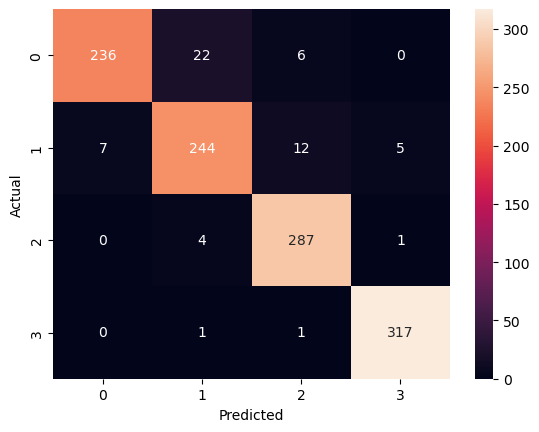

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       264
           1       0.90      0.91      0.91       268
           2       0.94      0.98      0.96       292
           3       0.98      0.99      0.99       319

    accuracy                           0.95      1143
   macro avg       0.95      0.95      0.95      1143
weighted avg       0.95      0.95      0.95      1143



In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred_classes))


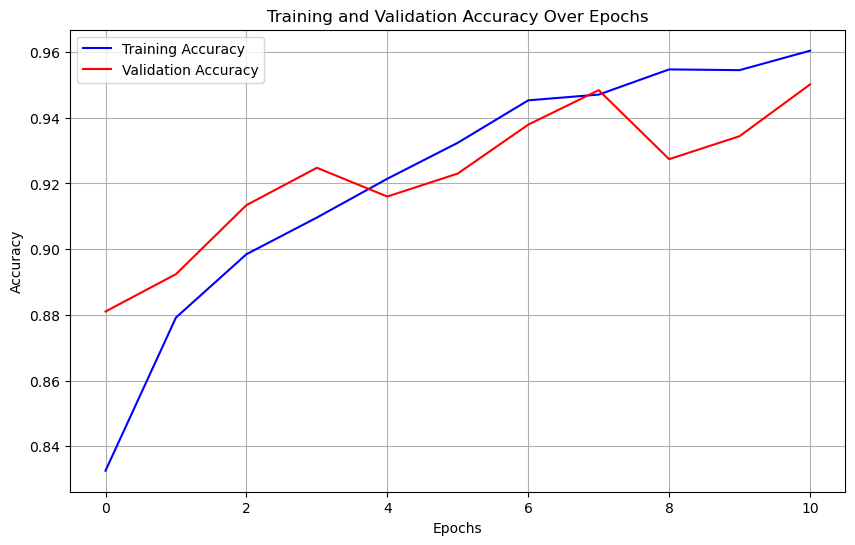

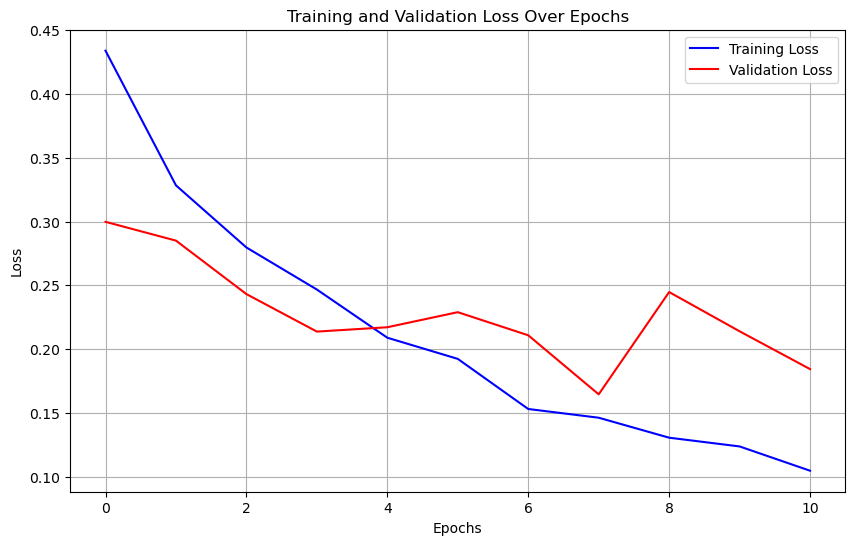

In [29]:
import matplotlib.pyplot as plt

# Assuming you have the `history` object from model.fit()
# history.history['accuracy'] gives the training accuracy over epochs
# history.history['val_accuracy'] gives the validation accuracy over epochs

# Plotting training and validation accuracy
plt.figure(figsize=(10, 6))

# Training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')

# Validation accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')

# Adding labels and title
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

# Optional: Plotting training and validation loss
plt.figure(figsize=(10, 6))

# Training loss
plt.plot(history.history['loss'], label='Training Loss', color='blue')

# Validation loss
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')

# Adding labels and title
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 823ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       264
           1       0.90      0.91      0.91       268
           2       0.94      0.98      0.96       292
           3       0.98      0.99      0.99       319

    accuracy                           0.95      1143
   macro avg       0.95      0.95      0.95      1143
weighted avg       0.95      0.95      0.95      1143



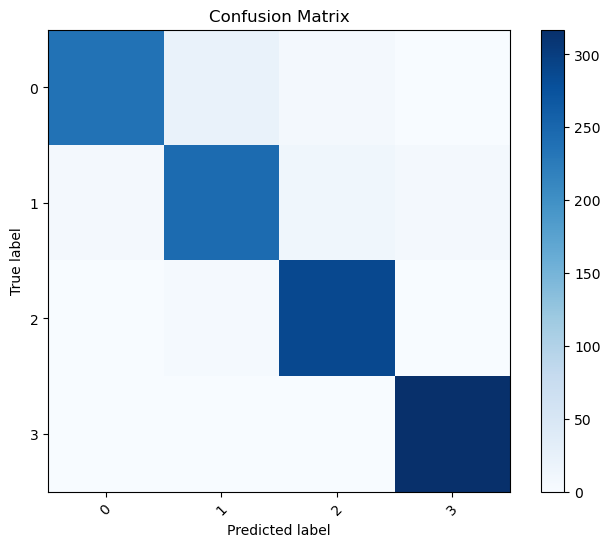

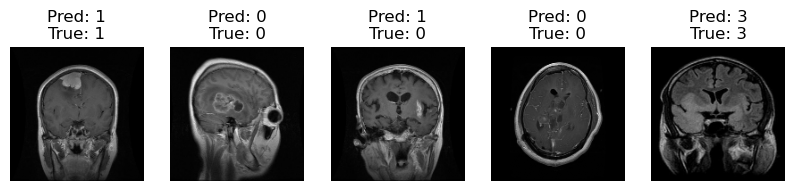

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Make Predictions
# Make predictions on the test set (X_test)
y_pred = model.predict(X_test)

# Since the predictions will have probabilities, we need to convert them to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Step 2: Compare with Actual Labels
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Step 3: Plot Confusion Matrix (Optional but useful for visualization)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test), rotation=45)
plt.yticks(tick_marks, np.unique(y_test))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Optional: Plot some images with predictions
plt.figure(figsize=(10, 10))
for i in range(5):  # Display 5 random images
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i])
    plt.title(f"Pred: {y_pred_classes[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.show()


In [34]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the trained model
model = tf.keras.models.load_model(r'C:\Users\asus\brain_tumor_model.keras')

# Load and preprocess the image
img_path = r"C:\Users\asus\archive\Testing\pituitary\Te-pi_0049.jpg"  # Provide the correct image path
img = image.load_img(img_path, target_size=(150, 150))  # Resize to the input size of the model

# Convert the image to a numpy array
img_array = image.img_to_array(img)

# Expand dimensions to match the model's input (batch of 1 image)
img_array = np.expand_dims(img_array, axis=0)

# Normalize the image (if needed, depending on your model's preprocessing)
img_array = img_array / 255.0

# Make a prediction
prediction = model.predict(img_array)

# Assuming a binary classification, get the predicted class
# For binary classification, the model might output a probability, 
# so we need to apply a threshold (e.g., 0.5) to decide the class.
predicted_class = np.argmax(prediction, axis=1)  # For multi-class classification

# For binary classification, you might use:
# predicted_class = 1 if prediction > 0.5 else 0

print(f"Predicted class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Predicted class: [2]


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Paths to your dataset
train_dir = r"C:\Users\asus\archive\Training"
val_dir = r"C:\Users\asus\archive\Testing"

# Image settings
IMG_SIZE = 224  # EfficientNetB0 default
BATCH_SIZE = 32

# Data augmentation and rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load EfficientNetB0 without top layer
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
base_model.trainable = False  # Freeze base initially

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Callbacks
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.2)

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

# Save model
model.save('brain_tumor_efficientnet.keras')


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_238']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


179/179 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.2620 - auc: 0.5036 - loss: 1.4175 - val_accuracy: 0.3089 - val_auc: 0.5650 - val_loss: 1.3838 - learning_rate: 0.0010
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.2841 - auc: 0.5386 - loss: 1.3811 - val_accuracy: 0.2288 - val_auc: 0.5207 - val_loss: 1.3905 - learning_rate: 0.0010
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.2849 - auc: 0.5330 - loss: 1.3813 - val_accuracy: 0.3089 - val_auc: 0.5730 - val_loss: 1.3746 - learning_rate: 0.0010
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.2827 - auc: 0.5356 - loss: 1.3805 - val_accuracy: 0.2586 - val_auc: 0.5511 - val_loss: 1.3804 - learning_rate: 0.0010
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.2925 - auc: 0.5459 - loss: 1.3784 - val_accuracy: 0.3089 - val_auc: 0.5800 - val_loss: 1.3808 - learning_rate: 0.0010
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 175s 979ms/step - accuracy: 0.2776 - auc: 0.53

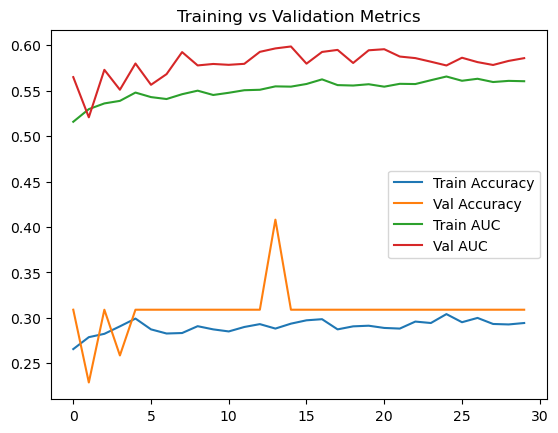

In [13]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.title('Training vs Validation Metrics')
plt.show()


In [16]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Parameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 4

train_dir = r"C:\Users\asus\archive\Training"
val_dir = r"C:\Users\asus\archive\Testing"


# Data Generators with EfficientNet preprocessing
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load EfficientNetB0 without top layers
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
base_model.trainable = False  # Freeze base initially

# Add custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=2, factor=0.2, verbose=1, monitor='val_loss'),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

# Initial Training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

# OPTIONAL: Fine-tuning (unfreeze base model)
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),  # Smaller LR
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

# Save final model
model.save("brain_tumor_efficientnet.keras")


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Epoch 1/30


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_479']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


179/179 ━━━━━━━━━━━━━━━━━━━━ 141s 694ms/step - accuracy: 0.3196 - auc: 0.5762 - loss: 1.4184 - val_accuracy: 0.6240 - val_auc: 0.8637 - val_loss: 0.9787 - learning_rate: 1.0000e-04
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 136s 661ms/step - accuracy: 0.6052 - auc: 0.8327 - loss: 0.9964 - val_accuracy: 0.7330 - val_auc: 0.9210 - val_loss: 0.7887 - learning_rate: 1.0000e-04
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 112s 623ms/step - accuracy: 0.6919 - auc: 0.8972 - loss: 0.8209 - val_accuracy: 0.7620 - val_auc: 0.9379 - val_loss: 0.6890 - learning_rate: 1.0000e-04
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 111s 619ms/step - accuracy: 0.7427 - auc: 0.9246 - loss: 0.7132 - val_accuracy: 0.7803 - val_auc: 0.9462 - val_loss: 0.6273 - learning_rate: 1.0000e-04
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 111s 622ms/step - accuracy: 0.7788 - auc: 0.9406 - loss: 0.6391 - val_accuracy: 0.7963 - val_auc: 0.9526 - val_loss: 0.5824 - learning_rate: 1.0000e-04
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 112s 626ms/

In [2]:
from tensorflow.keras.models import load_model

model = load_model("brain_tumor_efficientnet.keras")


model.summary()


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_505']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


179/179 ━━━━━━━━━━━━━━━━━━━━ 136s 664ms/step - accuracy: 0.3326 - auc: 0.5900 - loss: 1.4006 - val_accuracy: 0.6705 - val_auc: 0.8798 - val_loss: 0.9821 - learning_rate: 1.0000e-04
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 113s 631ms/step - accuracy: 0.6071 - auc: 0.8349 - loss: 1.0000 - val_accuracy: 0.7346 - val_auc: 0.9215 - val_loss: 0.7907 - learning_rate: 1.0000e-04
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 113s 633ms/step - accuracy: 0.6999 - auc: 0.8975 - loss: 0.8198 - val_accuracy: 0.7582 - val_auc: 0.9368 - val_loss: 0.6917 - learning_rate: 1.0000e-04
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 105s 589ms/step - accuracy: 0.7545 - auc: 0.9293 - loss: 0.6943 - val_accuracy: 0.7803 - val_auc: 0.9458 - val_loss: 0.6315 - learning_rate: 1.0000e-04
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 96s 534ms/step - accuracy: 0.7626 - auc: 0.9376 - loss: 0.6475 - val_accuracy: 0.7941 - val_auc: 0.9515 - val_loss: 0.5886 - learning_rate: 1.0000e-04
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 96s 537ms/st

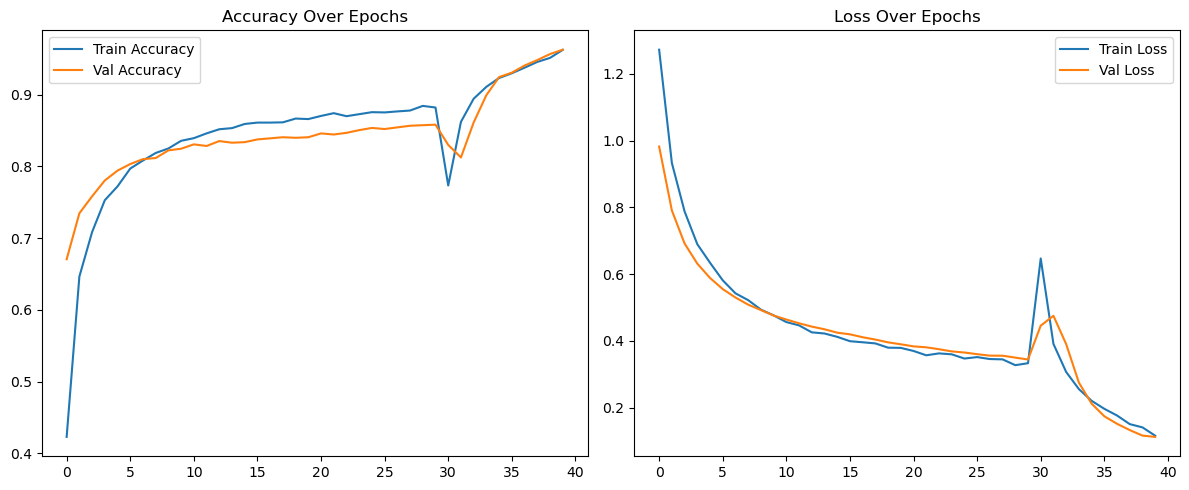

In [8]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import pickle
import os

# Parameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 4

train_dir = r"C:\Users\asus\archive\Training"
val_dir = r"C:\Users\asus\archive\Testing"

# Data generators
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Model
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=2, factor=0.2, verbose=1, monitor='val_loss'),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

# Train initial model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Save history
with open('history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# Fine-tune
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

# Save fine-tuning history
with open('fine_tune_history.pkl', 'wb') as f:
    pickle.dump(fine_tune_history.history, f)

# Save final model
model.save("brain_tumor_efficientnet.keras")

# Combine and plot histories
def combine_histories(h1, h2):
    history = {}
    for key in h1.history:
        history[key] = h1.history[key] + h2.history[key]
    return history

combined_history = combine_histories(history, fine_tune_history)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(combined_history['accuracy'], label='Train Accuracy')
plt.plot(combined_history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1, 2, 2)
plt.plot(combined_history['loss'], label='Train Loss')
plt.plot(combined_history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.tight_layout()
plt.savefig("training_plot.png")
plt.show()

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Epoch 1/30


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_746']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


179/179 ━━━━━━━━━━━━━━━━━━━━ 102s 533ms/step - accuracy: 0.3366 - auc: 0.5810 - loss: 1.4227 - val_accuracy: 0.6682 - val_auc: 0.8785 - val_loss: 0.9719 - learning_rate: 1.0000e-04
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 91s 509ms/step - accuracy: 0.6134 - auc: 0.8436 - loss: 0.9798 - val_accuracy: 0.7544 - val_auc: 0.9230 - val_loss: 0.7842 - learning_rate: 1.0000e-04
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 92s 511ms/step - accuracy: 0.7118 - auc: 0.9052 - loss: 0.8004 - val_accuracy: 0.7803 - val_auc: 0.9370 - val_loss: 0.6878 - learning_rate: 1.0000e-04
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 92s 513ms/step - accuracy: 0.7617 - auc: 0.9287 - loss: 0.6988 - val_accuracy: 0.7956 - val_auc: 0.9482 - val_loss: 0.6233 - learning_rate: 1.0000e-04
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 92s 516ms/step - accuracy: 0.7906 - auc: 0.9461 - loss: 0.6168 - val_accuracy: 0.8047 - val_auc: 0.9530 - val_loss: 0.5809 - learning_rate: 1.0000e-04
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 92s 513ms/step 

C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_746']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


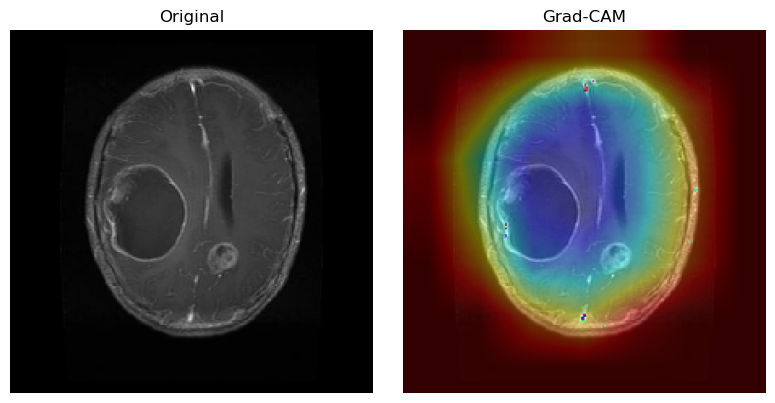

In [9]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.efficientnet import preprocess_input
import cv2
import random

# Paths

train_dir = r"C:\Users\asus\archive\Training"
val_dir = r"C:\Users\asus\archive\Testing"

# Parameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 4

# Data Generator
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical'
)

# Model
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.2, verbose=1),
    ModelCheckpoint("best_model.keras", save_best_only=True)
]

# Train
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS, callbacks=callbacks)

# Fine-tune
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=callbacks)

# Save Model
model.save("brain_tumor_efficientnet.keras")

# Grad-CAM visualization
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Display Grad-CAM
def display_gradcam(image_path, model, last_conv_layer_name="top_conv"):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    input_array = preprocess_input(np.expand_dims(img_array, axis=0))

    heatmap = make_gradcam_heatmap(input_array, model, last_conv_layer_name)

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + img_array
    superimposed_img = np.uint8(superimposed_img)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img_array.astype("uint8"))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM")
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage
sample_image = os.path.join(val_dir, random.choice(os.listdir(val_dir)), random.choice(os.listdir(os.path.join(val_dir, random.choice(os.listdir(val_dir))))))
display_gradcam(sample_image, model)

In [10]:
# Evaluate the model on the test data
test_loss, test_accuracy, test_auc = model.evaluate(val_generator, verbose=1)

# Print the results
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test AUC: {test_auc}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 429ms/step - accuracy: 0.9684 - auc: 0.9984 - loss: 0.0950
Test Loss: 0.1012091264128685
Test Accuracy: 0.9641494750976562
Test AUC: 0.9982687830924988


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Updated validation generator for TTA
val_datagen_tta = ImageDataGenerator(preprocessing_function=preprocess_input)

val_generator_tta = val_datagen_tta.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1311 images belonging to 4 classes.


In [13]:
def tta_predict(model, generator, tta_steps=10):
    predictions = []
    for i in range(tta_steps):
        print(f"TTA Step {i+1}/{tta_steps}")
        generator.reset()
        preds = model.predict(generator, verbose=0)
        predictions.append(preds)
    final_preds = np.mean(predictions, axis=0)
    return final_preds

In [14]:
# Run TTA
tta_preds = tta_predict(model, val_generator_tta, tta_steps=10)

# Get true and predicted classes
true_labels = val_generator_tta.classes
predicted_classes = np.argmax(tta_preds, axis=1)

# TTA Accuracy
tta_acc = np.mean(predicted_classes == true_labels)
print(f"\nTTA Accuracy: {tta_acc:.4f}")

TTA Step 1/10


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


TTA Step 2/10
TTA Step 3/10
TTA Step 4/10
TTA Step 5/10
TTA Step 6/10
TTA Step 7/10
TTA Step 8/10
TTA Step 9/10
TTA Step 10/10

TTA Accuracy: 0.9641



Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.93      0.95       300
  meningioma       0.92      0.93      0.93       306
     notumor       0.97      1.00      0.98       405
   pituitary       0.99      0.98      0.98       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



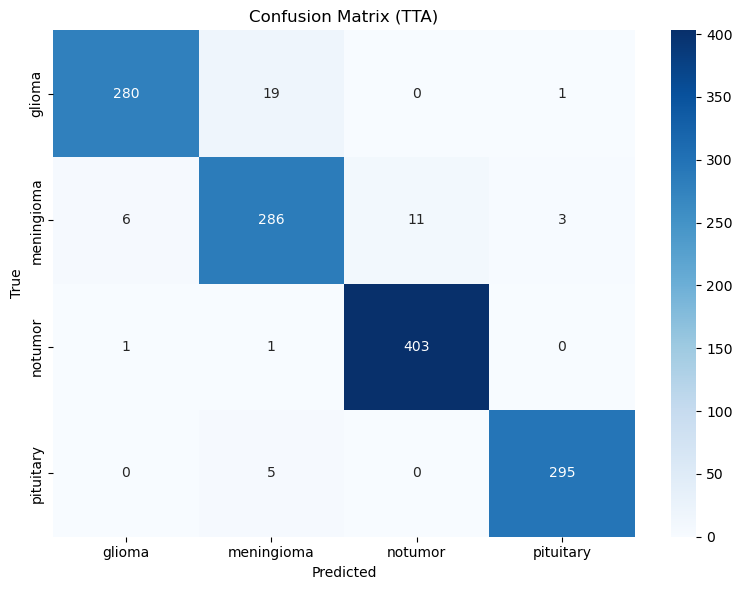

In [15]:
# Classification Report
class_labels = list(val_generator_tta.class_indices.keys())
print("\nClassification Report:")
print(classification_report(true_labels, predicted_classes, target_names=class_labels))

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title('Confusion Matrix (TTA)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [16]:
tta_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

tta_generator = tta_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1311 images belonging to 4 classes.


In [17]:
def tta_predict(model, generator, tta_steps=10):
    predictions = []
    for i in range(tta_steps):
        print(f"TTA Step {i+1}/{tta_steps}")
        generator.reset()
        preds = model.predict(generator, verbose=0)
        predictions.append(preds)
    final_preds = np.mean(predictions, axis=0)
    return final_preds

In [18]:
# Run TTA with augmentations
tta_preds_aug = tta_predict(model, tta_generator, tta_steps=10)

# Accuracy
true_labels = tta_generator.classes
predicted_classes = np.argmax(tta_preds_aug, axis=1)
tta_acc = np.mean(predicted_classes == true_labels)
print(f"\nTTA Accuracy (with augmentations): {tta_acc:.4f}")

TTA Step 1/10


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


TTA Step 2/10
TTA Step 3/10
TTA Step 4/10
TTA Step 5/10
TTA Step 6/10
TTA Step 7/10
TTA Step 8/10
TTA Step 9/10
TTA Step 10/10

TTA Accuracy (with augmentations): 0.9504


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Epoch 1/30


C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_987']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


179/179 ━━━━━━━━━━━━━━━━━━━━ 104s 537ms/step - accuracy: 0.2970 - auc: 0.5460 - loss: 1.4747 - val_accuracy: 0.6606 - val_auc: 0.8796 - val_loss: 0.9898 - learning_rate: 1.0000e-04
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 92s 515ms/step - accuracy: 0.5973 - auc: 0.8345 - loss: 1.0076 - val_accuracy: 0.7468 - val_auc: 0.9244 - val_loss: 0.7871 - learning_rate: 1.0000e-04
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 92s 514ms/step - accuracy: 0.7155 - auc: 0.9085 - loss: 0.7994 - val_accuracy: 0.7849 - val_auc: 0.9414 - val_loss: 0.6838 - learning_rate: 1.0000e-04
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 92s 512ms/step - accuracy: 0.7529 - auc: 0.9296 - loss: 0.7013 - val_accuracy: 0.8002 - val_auc: 0.9498 - val_loss: 0.6212 - learning_rate: 1.0000e-04
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 92s 512ms/step - accuracy: 0.7831 - auc: 0.9450 - loss: 0.6247 - val_accuracy: 0.8154 - val_auc: 0.9551 - val_loss: 0.5770 - learning_rate: 1.0000e-04
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 92s 514ms/step 

C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_987']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


TTA step 2/5
TTA step 3/5
TTA step 4/5
TTA step 5/5

Classification Report:

              precision    recall  f1-score   support

      glioma       0.98      0.92      0.95       300
  meningioma       0.90      0.94      0.92       306
     notumor       0.97      1.00      0.98       405
   pituitary       0.99      0.97      0.98       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



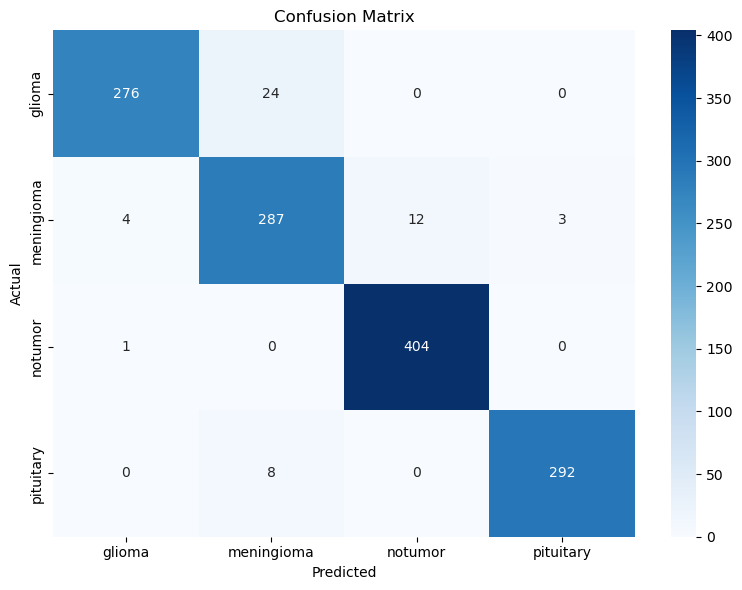

41/41 ━━━━━━━━━━━━━━━━━━━━ 17s 417ms/step - accuracy: 0.9463 - auc: 0.9964 - loss: 0.1362

Test Loss: 0.1079
Test Accuracy: 0.9603
Test AUC: 0.9980


In [21]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.efficientnet import preprocess_input
import cv2
import random

train_dir = r"C:\Users\asus\archive\Training"
val_dir = r"C:\Users\asus\archive\Testing"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 4

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.2, verbose=1),
    ModelCheckpoint("best_model.keras", save_best_only=True)
]

model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS, callbacks=callbacks)

base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=callbacks)

model.save("brain_tumor_efficientnet.keras")

def predict_with_tta(model, generator, steps=5):
    tta_preds = []
    for i in range(steps):
        print(f"TTA step {i+1}/{steps}")
        generator.reset()
        preds = model.predict(generator, verbose=0)
        tta_preds.append(preds)
    return np.mean(tta_preds, axis=0)

tta_predictions = predict_with_tta(model, val_generator, steps=5)
y_true = val_generator.classes
y_pred = np.argmax(tta_predictions, axis=1)

target_names = list(val_generator.class_indices.keys())
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

loss, acc, auc = model.evaluate(val_generator, verbose=1)
print(f"\nTest Loss: {loss:.4f}\nTest Accuracy: {acc:.4f}\nTest AUC: {auc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


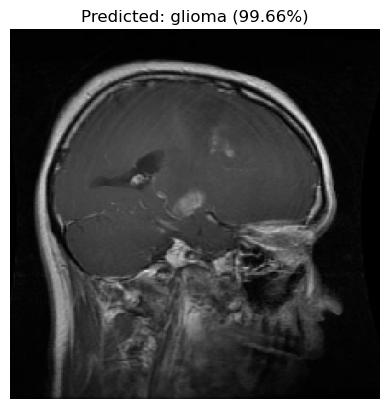

In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt

# Load your saved model
model = tf.keras.models.load_model("brain_tumor_efficientnet.keras")

# Path to your test image
img_path =r"C:\Users\asus\archive\Testing\glioma\Te-gl_0189.jpg" # <-- Change this to your image path

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Make prediction
pred = model.predict(img_array)
pred_class = np.argmax(pred)

# Get class names (update if different)
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']  # Change if needed
predicted_label = class_names[pred_class]

# Show image and prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_label} ({np.max(pred)*100:.2f}%)")
plt.axis("off")
plt.show()

In [13]:
# Check the layers of the model
for layer in model.layers:
    print(layer.name)

input_layer_2
rescaling_4
normalization_2
rescaling_5
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_squeeze
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_squeeze
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_dwconv_pad
block3a_dwconv
block3a_bn
block3a_activation
block3a_se_squeeze
block3a_se_reshape
block3a_se_reduce
block3a_se_

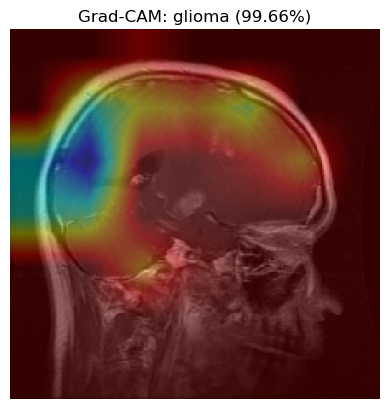

In [25]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Assuming you have the model loaded
conv_layer_name = "block7a_activation"  # Replace with your target layer

# Create a new model that will return both the final prediction and the output of the convolutional layer
last_conv_layer = model.get_layer(conv_layer_name)
model_with_conv_outputs = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.output, last_conv_layer.output]
)

# Prepare the image
img_array = np.expand_dims(img, axis=0)  # Add batch dimension
img_array = tf.image.resize(img_array, (224, 224))  # Resize if necessary

# Compute the gradients using GradientTape
with tf.GradientTape() as tape:
    tape.watch(img_array)
    preds, last_conv_output = model_with_conv_outputs(img_array)  # Get both predictions and convolutional layer output
    pred_class_idx = np.argmax(preds[0])  # Get the predicted class index
    class_output = preds[:, pred_class_idx]  # Output for the predicted class

# Compute the gradient of the predicted class with respect to the last convolutional layer
grads = tape.gradient(class_output, last_conv_output)

# Global average pooling of the gradients
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Get the output of the last convolutional layer
conv_outputs = last_conv_output[0]  # First image in the batch

# Weight the convolutional outputs by the gradients
heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)

# Post-process the heatmap
heatmap = np.maximum(heatmap, 0)  # ReLU
heatmap = heatmap / np.max(heatmap)  # Normalize

# Resize heatmap to match the input image size
heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))  # Remove .numpy()

# Superimpose the heatmap on the original image
img = np.array(img)
heatmap = np.uint8(255 * heatmap)  # Convert heatmap to 0-255
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

# Display the image and Grad-CAM overlay
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM: {predicted_label} ({np.max(preds)*100:.2f}%)")
plt.axis('off')
plt.show()

In [10]:
import os

image_folder = r"C:\Users\asus\OneDrive - Amity University\Desktop\real image"

print("Checking images in folder...")
files = os.listdir(image_folder)
print(f"Found {len(files)} files.")

for img_name in files:
    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        print(f"Processing image: {img_name}")
    else:
        print(f"Skipping file: {img_name} (not image)")

Checking images in folder...
Found 3 files.
Skipping file: glioma (not image)
Skipping file: meningioma (not image)
Skipping file: pituitary (not image)


In [12]:
import os



image_folder = r"C:\Users\asus\OneDrive - Amity University\Desktop\real image"

print("Checking images in folder and subfolders...")

for root, dirs, files in os.walk(image_folder):
    for img_name in files:
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, img_name)
            print(f"Found image: {img_path}")
        else:
            print(f"Skipping file: {img_name} (not image)")

print("Checking images in folder and subfolders...")

for root, dirs, files in os.walk(image_folder):
    for img_name in files:
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, img_name)
            print(f"Found image: {img_path}")
        else:
            print(f"Skipping file: {img_name} (not image)")

Checking images in folder and subfolders...
Found image: C:\Users\asus\OneDrive - Amity University\Desktop\real image\glioma\download.jpg
Found image: C:\Users\asus\OneDrive - Amity University\Desktop\real image\glioma\OIP (1).jpg
Found image: C:\Users\asus\OneDrive - Amity University\Desktop\real image\glioma\OIP.jpg
Found image: C:\Users\asus\OneDrive - Amity University\Desktop\real image\meningioma\download.jpg
Found image: C:\Users\asus\OneDrive - Amity University\Desktop\real image\meningioma\OIP (1).jpg
Found image: C:\Users\asus\OneDrive - Amity University\Desktop\real image\meningioma\OIP.jpg
Found image: C:\Users\asus\OneDrive - Amity University\Desktop\real image\pituitary\MRI-finding-of-pituitary-tumors.png
Found image: C:\Users\asus\OneDrive - Amity University\Desktop\real image\pituitary\OIP.jpg
Found image: C:\Users\asus\OneDrive - Amity University\Desktop\real image\pituitary\pituitary-tumor-MRI-1.jpg
Checking images in folder and subfolders...
Found image: C:\Users\asus

In [14]:
print("Preds shape:", preds.shape)
print("Preds:", preds)

Preds shape: (1, 4)
Preds: [[1.5448400e-12 9.5262760e-05 2.3381326e-02 9.7652346e-01]]


Starting prediction and Grad-CAM visualization on all images...
Processing: C:\Users\asus\OneDrive - Amity University\Desktop\real image\glioma\download.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Preds shape: (1, 4)
Preds: [[0.01011995 0.9727749  0.01603325 0.00107184]]
Prediction: meningioma, Confidence: 97.28%


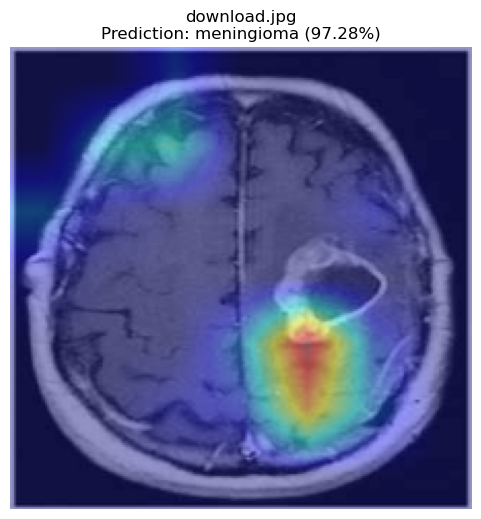

Processing: C:\Users\asus\OneDrive - Amity University\Desktop\real image\glioma\OIP (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Preds shape: (1, 4)
Preds: [[1.5448400e-12 9.5262760e-05 2.3381326e-02 9.7652346e-01]]
Prediction: no_tumor, Confidence: 97.65%


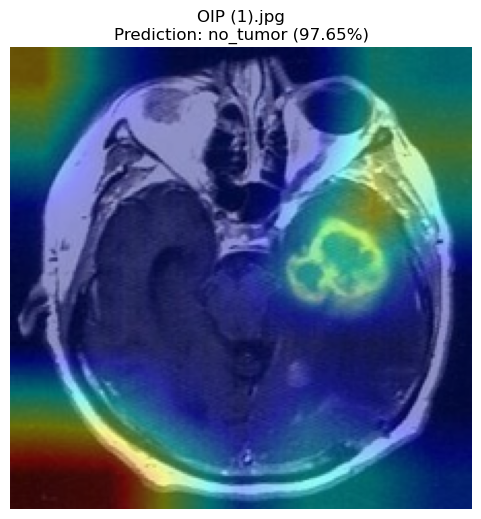

Processing: C:\Users\asus\OneDrive - Amity University\Desktop\real image\glioma\OIP.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Preds shape: (1, 4)
Preds: [[0.00135057 0.07108709 0.9039755  0.02358686]]
Prediction: pituitary, Confidence: 90.40%


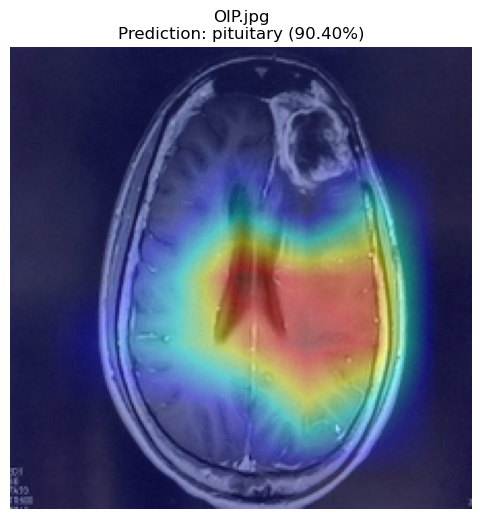

Processing: C:\Users\asus\OneDrive - Amity University\Desktop\real image\meningioma\download.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Preds shape: (1, 4)
Preds: [[0.00193564 0.48476246 0.07235209 0.44094977]]
Prediction: meningioma, Confidence: 48.48%


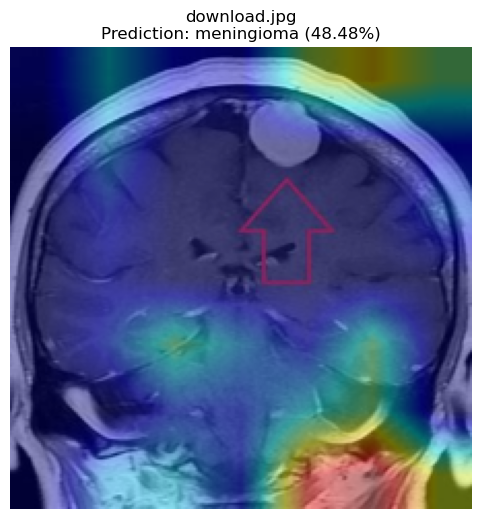

Processing: C:\Users\asus\OneDrive - Amity University\Desktop\real image\meningioma\OIP (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Preds shape: (1, 4)
Preds: [[0.7763798  0.21258572 0.01023794 0.00079646]]
Prediction: glioma, Confidence: 77.64%


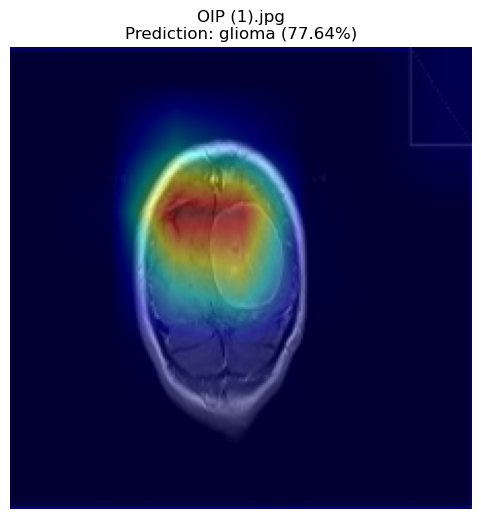

Processing: C:\Users\asus\OneDrive - Amity University\Desktop\real image\meningioma\OIP.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Preds shape: (1, 4)
Preds: [[0.00431893 0.85665715 0.03307509 0.10594881]]
Prediction: meningioma, Confidence: 85.67%


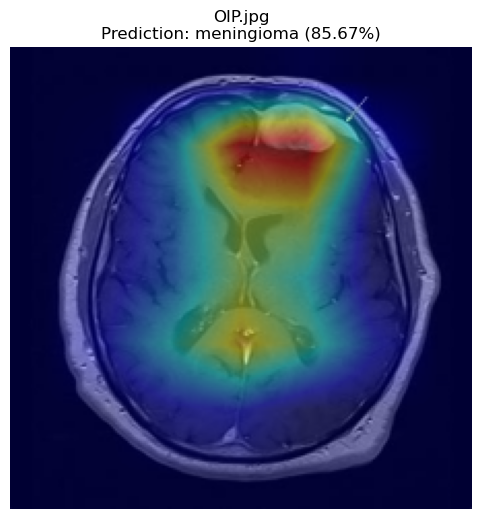

Processing: C:\Users\asus\OneDrive - Amity University\Desktop\real image\pituitary\MRI-finding-of-pituitary-tumors.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Preds shape: (1, 4)
Preds: [[0.00102324 0.08814494 0.9065961  0.00423564]]
Prediction: pituitary, Confidence: 90.66%


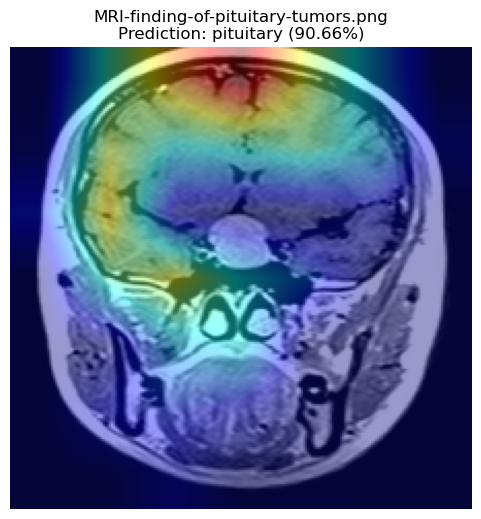

Processing: C:\Users\asus\OneDrive - Amity University\Desktop\real image\pituitary\OIP.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Preds shape: (1, 4)
Preds: [[0.0295075  0.01573223 0.9202893  0.03447104]]
Prediction: pituitary, Confidence: 92.03%


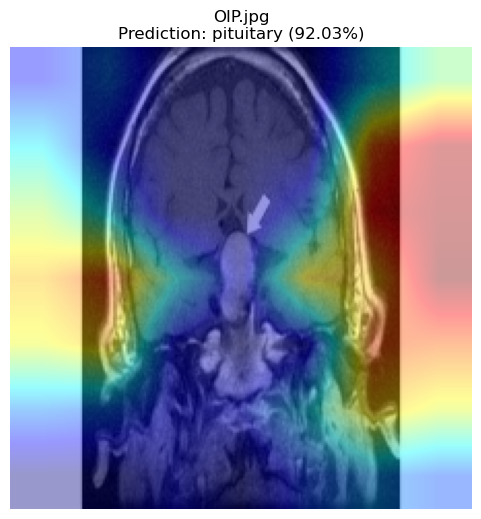

Processing: C:\Users\asus\OneDrive - Amity University\Desktop\real image\pituitary\pituitary-tumor-MRI-1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Preds shape: (1, 4)
Preds: [[0.02482992 0.7229413  0.19828102 0.05394779]]
Prediction: meningioma, Confidence: 72.29%


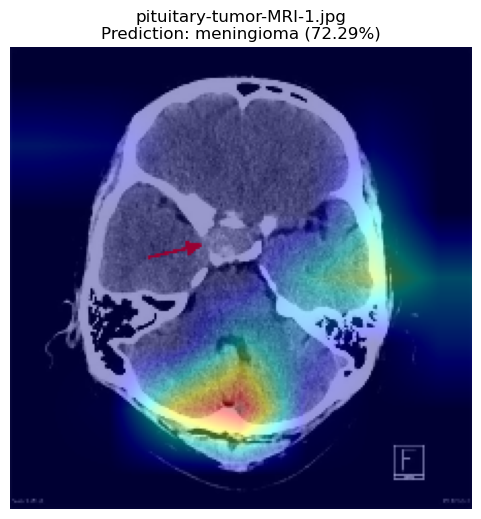

In [15]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import cv2

# Load your model
model = tf.keras.models.load_model("brain_tumor_efficientnet.keras")

# Update this list as per your actual 4 classes
class_names = ['glioma', 'meningioma', 'pituitary', 'no_tumor']  

image_folder = r"C:\Users\asus\OneDrive - Amity University\Desktop\real image"

def generate_gradcam(img_array, model, last_conv_layer_name="block7a_activation"):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

print("Starting prediction and Grad-CAM visualization on all images...")

for root, dirs, files in os.walk(image_folder):
    for img_name in files:
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, img_name)
            print(f"Processing: {img_path}")

            # Load and preprocess image
            img = image.load_img(img_path, target_size=(224, 224))
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)

            # Prediction
            preds = model.predict(img_array)
            print("Preds shape:", preds.shape)
            print("Preds:", preds)

            if preds.size == 0 or preds.shape[1] != len(class_names):
                print("Model output shape does not match number of classes. Skipping this image.")
                continue

            predicted_class = class_names[np.argmax(preds)]
            confidence = np.max(preds)
            print(f"Prediction: {predicted_class}, Confidence: {confidence*100:.2f}%")

            # Grad-CAM heatmap
            heatmap = generate_gradcam(img_array, model)
            heatmap = cv2.resize(heatmap, (224, 224))
            heatmap = np.uint8(255 * heatmap)
            heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

            original = cv2.imread(img_path)
            original = cv2.resize(original, (224, 224))
            superimposed_img = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

            # Show image with prediction and Grad-CAM
            plt.figure(figsize=(6, 6))
            plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
            plt.title(f"{os.path.basename(img_path)}\nPrediction: {predicted_class} ({confidence*100:.2f}%)")
            plt.axis('off')
            plt.show()